# Mapas y Heatmaps: Territorio-Año
Este cuaderno visualiza patrones espaciotemporales mediante mapas de calor.

In [1]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != 'MD_Proyecto1':
    for parent in PROJECT_ROOT.parents:
        if parent.name == 'MD_Proyecto1':
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import data_pipeline as dp
dp = importlib.reload(dp)

panel = dp.build_panel(force_rebuild=False, only_common_years=False).dropna(subset=['departamento', 'anio']).copy()
panel[['divorcios_total', 'vif_total']] = panel[['divorcios_total', 'vif_total']].fillna(0)
print(f"Panel cargado: {len(panel)} registros")

sns.set_style('white')

Panel cargado: 351 registros


## 1. Heatmap: Divorcios por Departamento y Año
Visualizamos la evolución de divorcios en cada departamento.

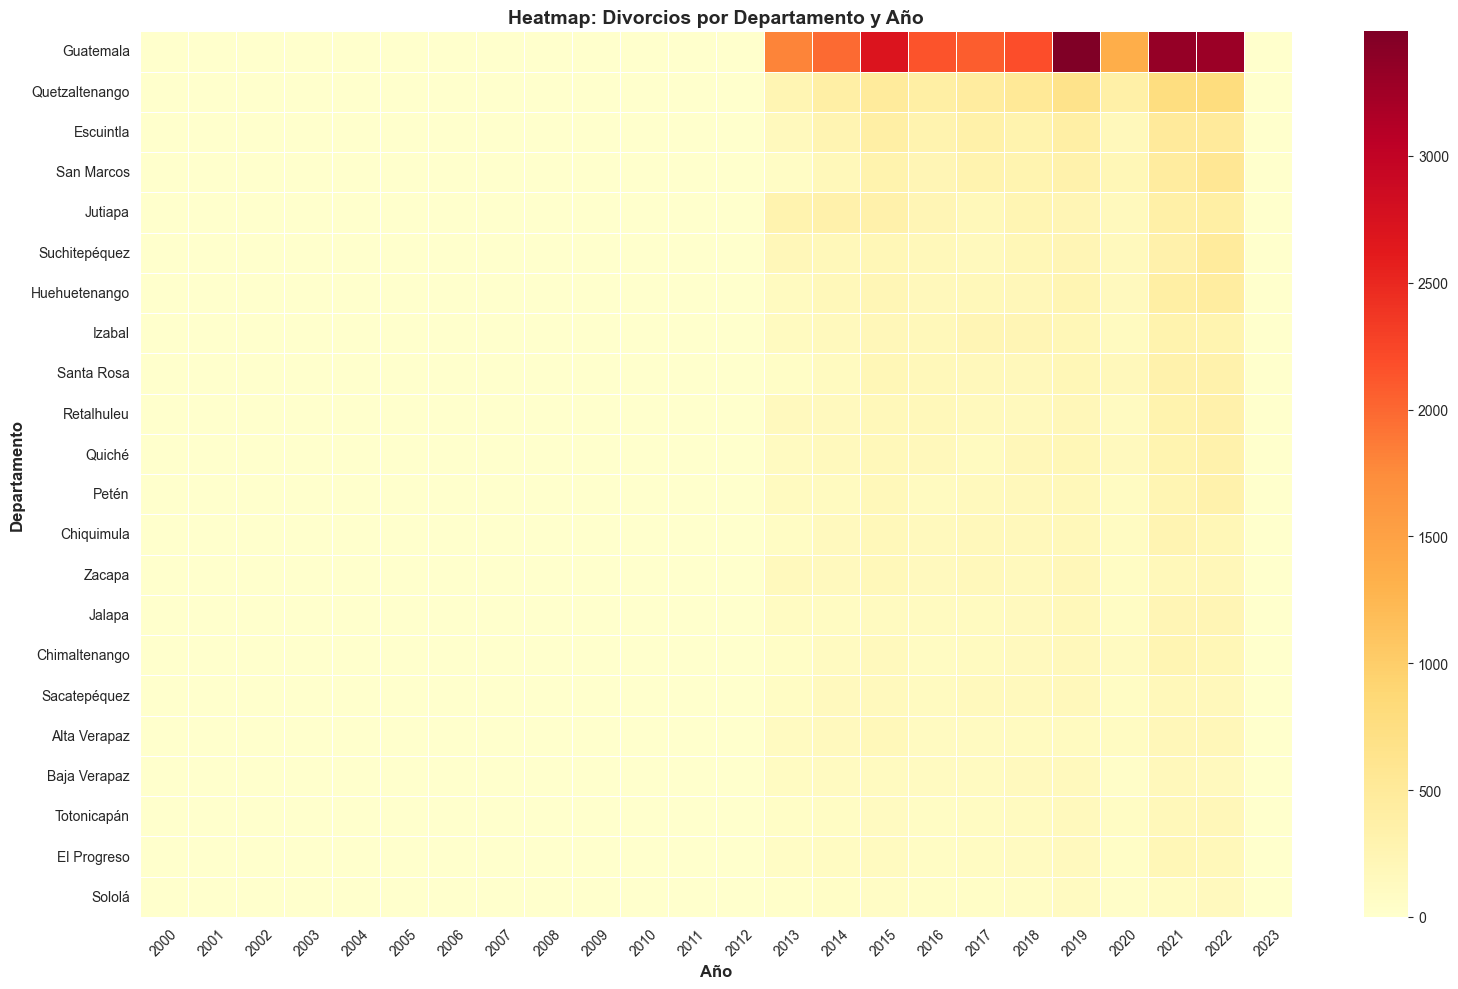

In [2]:
pivot_divorcios = panel.pivot_table(
    values='divorcios_total',
    index='departamento',
    columns='anio',
    aggfunc='sum',
    fill_value=0
)

pivot_divorcios['total'] = pivot_divorcios.sum(axis=1)
pivot_divorcios = pivot_divorcios.sort_values('total', ascending=False).drop('total', axis=1)

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(pivot_divorcios, cmap='YlOrRd', annot=False, linewidths=0.5, ax=ax)
ax.set_xlabel('Año', fontsize=12, fontweight='bold')
ax.set_ylabel('Departamento', fontsize=12, fontweight='bold')
ax.set_title('Heatmap: Divorcios por Departamento y Año', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Conclusión**: El heatmap revela que Guatemala capital concentra la mayoría de divorcios.
Se observan patrones de crecimiento en departamentos urbanos.

## 2. Heatmap: VIF por Departamento y Año
Analizamos los patrones espaciotemporales de VIF.

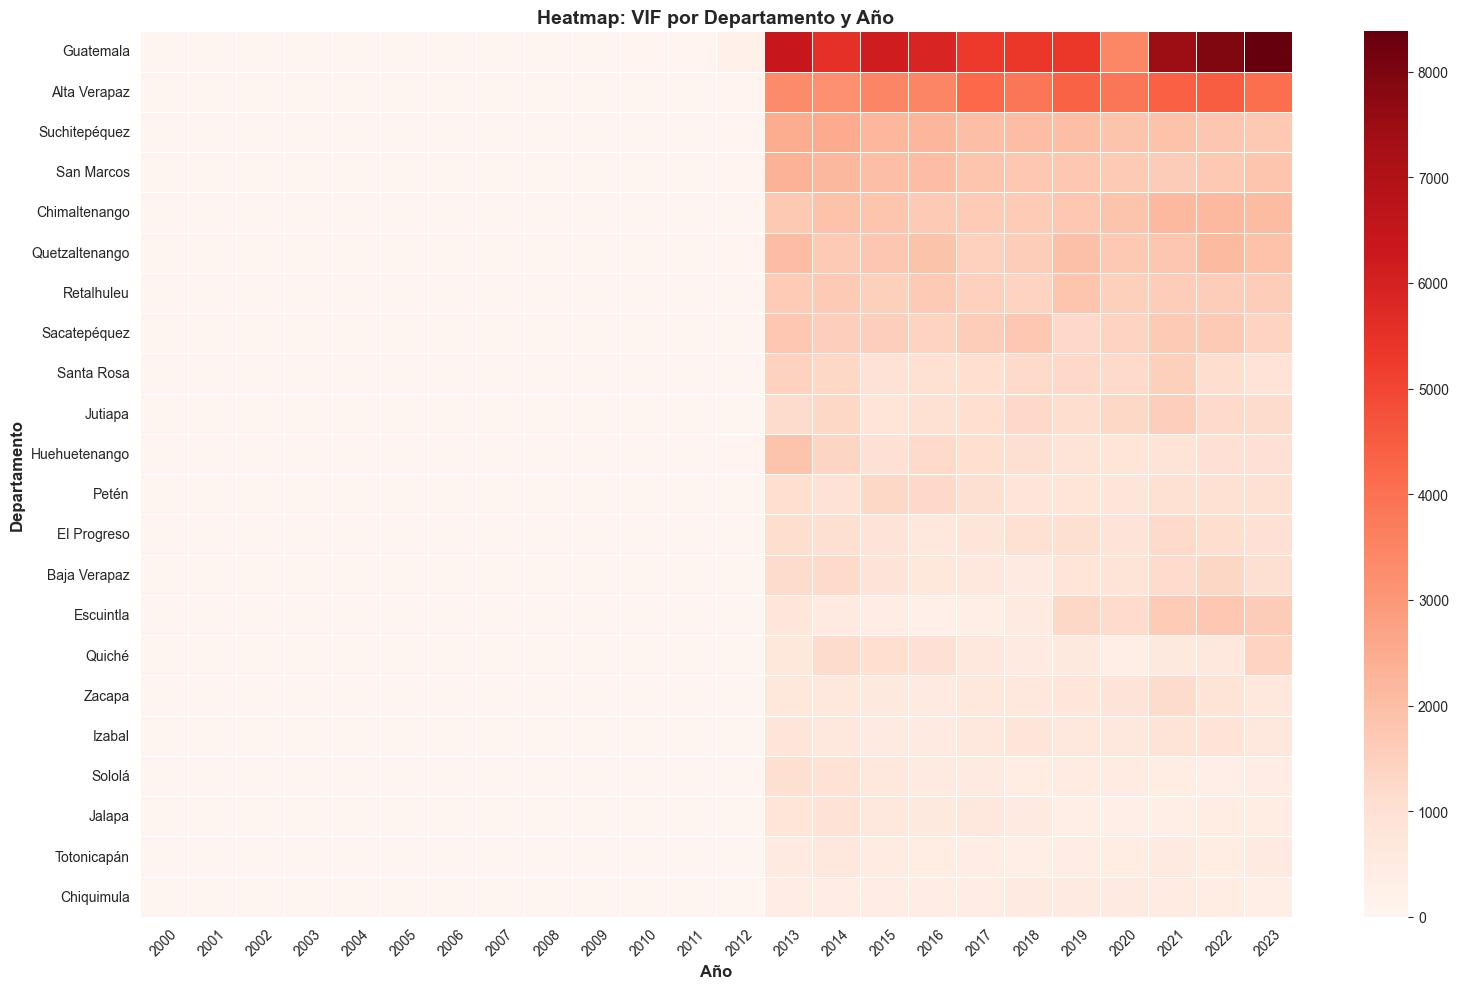

In [3]:
pivot_vif = panel.pivot_table(
    values='vif_total',
    index='departamento',
    columns='anio',
    aggfunc='sum',
    fill_value=0
)

pivot_vif['total'] = pivot_vif.sum(axis=1)
pivot_vif = pivot_vif.sort_values('total', ascending=False).drop('total', axis=1)

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(pivot_vif, cmap='Reds', annot=False, linewidths=0.5, ax=ax)
ax.set_xlabel('Año', fontsize=12, fontweight='bold')
ax.set_ylabel('Departamento', fontsize=12, fontweight='bold')
ax.set_title('Heatmap: VIF por Departamento y Año', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Conclusión**: La VIF muestra patrón similar con alta concentración en Guatemala capital.
La intensidad revela años con mayor actividad de denuncia.

## 3. Matriz de Correlación por Departamento
Analizamos la relación entre divorcios y VIF por departamento.

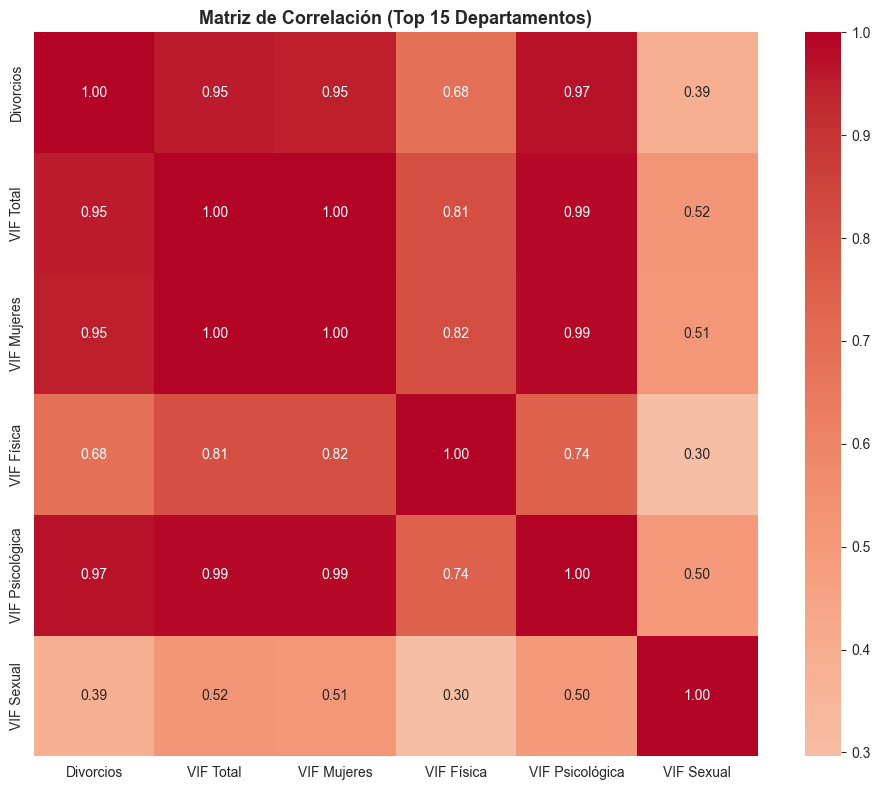

In [4]:
dept_summary = panel.groupby('departamento').agg({
    'divorcios_total': 'sum',
    'vif_total': 'sum',
    'vif_sexo_mujeres': 'sum',
    'vif_tipo_fisica': 'sum',
    'vif_tipo_psicologica': 'sum',
    'vif_tipo_sexual': 'sum'
}).sort_values('divorcios_total', ascending=False).head(15)

dept_summary.columns = ['Divorcios', 'VIF Total', 'VIF Mujeres', 'VIF Física', 'VIF Psicológica', 'VIF Sexual']
corr_matrix = dept_summary.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Matriz de Correlación (Top 15 Departamentos)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusión**: Existe alta correlación entre divorcios y VIF a nivel departamental,
sugiriendo factores estructurales comunes como urbanización y servicios.